# <b>FloodGrid — Flood Event Analysis for Nairobi County Capstone Project</b>
Author: Stacy Mwangi
<br>Date: 2025-2026</br>
## Environmental Research Question: 
- What are the trends in fuel economy across different vehicle classes?
- How do different factors like engine size and vehicle weight affect fuel economy?

Link to GitHub repository: [GitHub Repository](<insert link here>)

## Loading Data
Relevant Lectures:
<br>**Course 1, Module 1**: "Getting to know Environmental Data" by Eli — Covers types and sources of data.</br>
<br>**Course 2, Module 5**: "Sources of Environmental Data" by Jess O'Toole — Discusses where to find free/accessible data sources.</br>

In [3]:
# Load libraries
library(sf)          
library(ggplot2)    
library(dplyr)      
library(terra)     
library(tidyterra)   
library(knitr)
library(lubridate)
library(exactextractr)
library(viridis)
library(scales)
library(forcats)
setwd("/home/user/Capstone-Project-Template/CRUM_Nairobi/data")

# Load dataset
subcounties <- st_read("processed_data/gadm41_KEN_2.shp")%>% filter(NAME_1 == "Nairobi")
subcounty <- st_read("/home/user/Capstone-Project-Template/CRUM_Nairobi/data/processed_data/gadm41_KEN_2.shp") %>% filter(NAME_2 == "Kasarani")
subcounties
#subcounty <- st_read("processed_data/gadm41_KEN_2.shp") %>%
#  filter(NAME_2 %in% c(
#    "Dagoretti North",
#    "Dagoretti South",
#    "Embakasi Central",
#    "Embakasi East",
#    "Embakasi North",
#    "Embakasi South",
#    "Embakasi West",
#    "Kamukunji",
#    "Kasarani",
#    "Kibra",
#    "Langata",
#    "Makadara",
#    "Mathare",
#    "Roysambu",
#    "Ruaraka",
#    "Starehe",
#    "Westlands"
#  ))
roads <- st_read("processed_data/nairobi_roads_clean.gpkg")
pop <- terra::rast("processed_data/nairobi_population_density.tif") 
flood_data <- st_read("processed_data/ai4g-flood-dataset.geojson")

# Display first few rows of the dataset
head(flood_data)

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE




Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




terra 1.8.60



...

Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<MULTIPOLYGON [°]>
1,KEN.30.1_1,KEN,Kenya,KEN.30_1,Nairobi,NA,Dagoretti North,NA,NA,Constituency,Constituency,275,NA,MULTIPOLYGON (((36.76082 -1...
2,KEN.30.2_1,KEN,Kenya,KEN.30_1,Nairobi,NA,Dagoretti South,NA,NA,Constituency,Constituency,276,NA,MULTIPOLYGON (((36.75381 -1...
3,KEN.30.3_1,KEN,Kenya,KEN.30_1,Nairobi,NA,Embakasi Central,NA,NA,Constituency,Constituency,284,NA,MULTIPOLYGON (((36.9181 -1....
4,KEN.30.4_1,KEN,Kenya,KEN.30_1,Nairobi,NA,Embakasi East,NA,NA,Constituency,Constituency,285,NA,MULTIPOLYGON (((36.97557 -1...
5,KEN.30.5_1,KEN,Kenya,KEN.30_1,Nairobi,NA,Embakasi North,NA,NA,Constituency,Constituency,283,NA,MULTIPOLYGON (((36.89368 -1...
6,KEN.30.6_1,KEN,Kenya,KEN.30_1,Nairobi,NA,Embakasi South,NA,NA,Constituency,Constituency,282,NA,MULTIPOLYGON (((36.9065 -1....
7,KEN.30.7_1,KEN,Kenya,KEN.30_1,Nairobi,NA,Embakasi West,NA,NA,Constituency,Constituency,286,NA,MULTIPOLYGON (((36.88592 -1...
8,KEN.30.8_1,KEN,Kenya,KEN.30_1,Nairobi,NA,Kamukunji,NA,NA,Constituency,Constituency,288,NA,MULTIPOLYGON (((36.85174 -1...
9,KEN.30.9_1,KEN,Kenya,KEN.30_1,Nairobi,NA,Kasarani,NA,NA,Constituency,Constituency,280,NA,MULTIPOLYGON (((37.00649 -1...


Reading layer `roads_clean' from data source 
  `/home/user/Capstone-Project-Template/CRUM_Nairobi/data/processed_data/nairobi_roads_clean.gpkg' 
  using driver `GPKG'
Simple feature collection with 25898 features and 8 fields
Geometry type: MULTILINESTRING
Dimension:     XY
Bounding box:  xmin: 36.65601 ymin: -1.441433 xmax: 37.10801 ymax: -1.155555
Geodetic CRS:  WGS 84


Reading layer `ai4g-flood-dataset' from data source 
  `/home/user/Capstone-Project-Template/CRUM_Nairobi/data/processed_data/ai4g-flood-dataset.geojson' 
  using driver `GeoJSON'
Simple feature collection with 51891 features and 15 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 36.67542 ymin: -1.433578 xmax: 37.10191 ymax: -1.162271
Geodetic CRS:  WGS 84


,year,month,day,lat,lon,filename,land_cover,dem_metric,dem_metr_1,soil_moist,soil_moi_1,soil_moi_2,soil_moi_3,temp,edge_false,geometry
,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<POINT [°]>
1,2018,1,29,-1.433578,36.94641,S1B_IW_GRDH_1SDV_20180129T031116_20180129T031139_009380_010D91-20m,20,0.96,5.23,2.2,-0.96,3.5,0.15,14.4,TRUE,POINT (36.94641 -1.433578)
2,2017,1,16,-1.433247,36.95321,S1A_IW_GRDH_1SSV_20170116T031152_20170116T031217_014851_018364-20m,30,1.76,3.60,3.0,-0.84,2.0,-0.26,14.5,TRUE,POINT (36.95321 -1.433247)
3,2017,8,18,-1.433098,36.95318,S1A_IW_GRDH_1SDV_20170818T154751_20170818T154816_017979_01E2BF-20m,30,1.74,3.60,5.7,-0.44,1.0,-0.53,12.9,TRUE,POINT (36.95318 -1.433098)
4,2017,1,16,-1.433066,36.95321,S1A_IW_GRDH_1SSV_20170116T031152_20170116T031217_014851_018364-20m,30,1.74,3.60,3.0,-0.84,2.0,-0.26,14.5,TRUE,POINT (36.95321 -1.433066)
5,2017,9,28,-1.433000,36.95381,S1A_IW_GRDH_1SDV_20170928T155556_20170928T155621_018577_01F511-20m,30,1.86,4.06,5.3,-0.49,1.0,-0.53,14.0,TRUE,POINT (36.95381 -1.433)
6,2018,2,19,-1.432999,36.95281,S1A_IW_GRDH_1SDV_20180219T155553_20180219T155618_020677_0236B3-20m,30,1.88,3.32,13.7,0.76,6.2,0.87,15.2,TRUE,POINT (36.95281 -1.432999)


## Cleaning Data
Relevant Lectures:
<br>**Course 3, Module 10**: "Data Cleaning Pt. 1" and "Data Cleaning Pt. 2" by JRS — Introduces key principles and practical data-cleaning techniques in R.</br>
<br>**Course 3, Module 8**: "Using EDA to Clean Data" by Angel — Discusses identifying common issues in data and addressing them.</br>

In [4]:
# Check CRS compatibility
cat("Flood Data CRS:\n", st_crs(flood_data)$input, "\n\n")
cat("Population CRS:\n", st_crs(pop)$input, "\n\n")
cat("Roads CRS:\n", st_crs(roads)$input, "\n\n")
cat("Subcounty CRS:\n", st_crs(subcounty)$input, "\n\n")

# Transform all data to the required CRS
target_crs <- "EPSG:32737"

flood_data <- st_transform(flood_data, target_crs)
roads <- st_transform(roads, target_crs)
subcounty <- st_transform(subcounty, target_crs)
pop <- terra::project(pop, target_crs)

# Clip our datasets from county to subcounty level
roads_clip <- st_filter(roads, subcounty, .predicate = st_intersects)
flood_clip <- st_filter(flood_data, subcounty, .predicate = st_intersects)
pop_clip <- pop |> crop(subcounty) |> mask(subcounty)

#Create date and season columns
flood_clip <- flood_clip %>%
  mutate(date = make_date(year, month, day),
         month_name = month(date, label = TRUE),
        season = case_when(month %in% c(12, 1, 2) ~ "DJF (Dry)",
                          month %in% c(3, 4, 5) ~ " MAM (Long Rains)",
                          month %in% c(6, 7, 8) ~ "JJA (Dry)",
                          month %in% c(9, 10, 11) ~ "SON (Short Rains)"
                          ),
         year_month = floor_date(date, "month")
        )

# Summary of the cleaned dataset
summary_stats <- flood_clip %>%
  summarise(
  total_events = n(),
  years_covered = n_distinct(year),
  start_year = min(year),
  end_year= max(year),
  avg_events_per_year = n() / n_distinct(year),
  peak_month = names(which.max(table(month))),
  most_vulnerable_landcover = names(which.max(table(land_cover)))
  )
print(summary_stats)

Flood Data CRS:
 WGS 84 



Population CRS:
 WGS 84 



Roads CRS:
 WGS 84 



Subcounty CRS:
 WGS 84 



Simple feature collection with 1 feature and 7 fields
Geometry type: MULTIPOINT
Dimension:     XY
Bounding box:  xmin: 263873.8 ymin: 9856144 xmax: 288802 ymax: 9866516
Projected CRS: WGS 84 / UTM zone 37S
  total_events years_covered start_year end_year avg_events_per_year peak_month
1        11412             9       2014     2024                1268          1
  most_vulnerable_landcover                       geometry
1                        30 MULTIPOINT ((263873.8 98638...


## Exploratory Data Analysis (EDA)
Relevant Lectures:
<br>**Course 3, Module 9**: "Conducting Exploratory Data Analysis (EDA)" by JRS — Introduces how to explore relationships between variables and visualise data.</br>
<br>**Course 3, Module 10**: "Creating Data Visualizations for EDA" by JRS — Focuses on visualizing relationships between variables using linear regression and other plots.</br>

In [5]:
# Annual frequency
annual_freq <- flood_clip %>%
  count(year)

# Monthly patterns
monthly_patterns <- flood_clip %>%
  count(month)%>%
  arrange(month)
monthly_patterns
#Land cover vulnerability
landcover_stats <- flood_clip %>%
  count(land_cover, sort = TRUE)%>%
  mutate(percentage = n / sum(n) * 100,
        cumulative_pct = cumsum(percentage))

print(annual_freq)
print(monthly_patterns)
print(landcover_stats)
# Identify recurrung flood locatons
spatial_buffer <- 30
flood_buffers <- flood_clip %>%
    st_buffer(dist = spatial_buffer)
# Visualization

# Ensure 'year' exists and is numeric
stopifnot("year" %in% names(flood_clip))

annual_freq <- flood_clip %>%
  count(year) %>%
  arrange(year)

# Nice integer breaks for y-axis
y_breaks <- scales::pretty_breaks(n = 6)

p_annual <- ggplot(annual_freq, aes(x = year, y = n)) +
  geom_col(fill = viridis::viridis(1, begin = 0.25, end = 0.25), width = 0.7) +
  geom_text(aes(label = scales::comma(n)), vjust = -0.35, size = 3.5, color = "gray20") +
  scale_x_continuous(breaks = seq(min(annual_freq$year), max(annual_freq$year), by = 1)) +
  scale_y_continuous(labels = scales::comma, breaks = y_breaks) +
  labs(
    title = "Annual Flood Detections (Kasarani)",
    subtitle = paste0(min(annual_freq$year), "–", max(annual_freq$year)),
    x = "Year",
    y = "Detections (count)",
    caption = "Source: AI4G flood dataset; clipped to Kasarani"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

p_annual

p_month_totals <- ggplot(monthly_patterns, aes(x = month, y = n)) +
  geom_col(fill = viridis::viridis(12, option = "C")[as.integer(monthly_patterns$month)], width = 0.7) +
  geom_text(aes(label = scales::comma(n)), vjust = -0.35, size = 3.3, color = "gray20") +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Monthly Flood Detections (All Years Combined)",
    x = "Month",
    y = "Detections (count)"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"), panel.grid.minor = element_blank())

p_month_totals



In [6]:
# analysing flood reccurrence - how many times has affected the same location
# method: create buffere around points and find intersections
grid_size <- 100

flood_counts <- flood_clip %>%
  mutate(cell_x = floor(st_coordinates(.)[,1]/grid_size)*grid_size,
        cell_y = floor(st_coordinates(.)[,2]/grid_size)*grid_size
        )%>%
  group_by(cell_x,cell_y)%>%
  summarise(
  flood_frequency = n(),
  unique_locations = n_distinct(geometry),
  first_flood = min(date),
  last_flood = max(date),
  .groups = "drop"
  )

#summary table
location_frequency <- flood_counts %>%
  #st_drop_geometry()%>%
  #count(flood_frequency)%>%
  arrange(desc(last_flood))
head(location_frequency)

cell_x,cell_y,flood_frequency,unique_locations,first_flood,last_flood,geometry
<dbl>,<dbl>,<int>,<int>,<date>,<date>,<GEOMETRY [m]>
274600,9861500,7,7,2016-05-31,2024-05-01,MULTIPOINT ((274646.7 98615...
274800,9861200,1,1,2024-05-01,2024-05-01,POINT (274847.3 9861282)
283600,9866100,7,7,2018-01-29,2024-05-01,MULTIPOINT ((283629.9 98661...
285300,9856300,1,1,2024-05-01,2024-05-01,POINT (285362 9856347)
285400,9856200,2,2,2018-04-23,2024-05-01,MULTIPOINT ((285422.4 98562...
285500,9856300,1,1,2024-05-01,2024-05-01,POINT (285542.5 9856308)


In [7]:
#analysing population exposure

#create population grid 
population_grid <- flood_counts %>%
  distinct(cell_x, cell_y)%>%
  mutate(geometry = purrr::map2(cell_x, cell_y, ~{
      st_polygon(list(matrix(c(.x, .y,
                              .x + grid_size, .y,
                              .x + grid_size, .y + grid_size,
                               .x, .y + grid_size,
                               .x, .y
                              ), ncol = 2, byrow = TRUE)))
  })
        )%>%
  st_as_sf(crs = st_crs(pop_clip))
#plot(population_grid)

#extract sum of population per grid cell
population_grid$population <- 
exact_extract(
  pop_clip,
  population_grid,
  fun = "sum",
  progress = FALSE
)

#replavce NA with 0
population_grid$population <- replace_na(population_grid$population,0)


#join population to xisting flood frequency analysis
flood_population <- flood_counts %>%
  left_join(st_drop_geometry(population_grid),
           by = c("cell_x", "cell_y")
           )%>%
 mutate(population_exposed = population * flood_frequency,
       risk_category = case_when(flood_frequency >= 10 & population > 100 ~ "CRITICAL: Dense Chronic",
                                flood_frequency >= 10 ~ "HIGH: Chronic Flood Zone",
                                flood_frequency >= 5 & population > 50 ~ "ELEVATED: Populated Repeat",
                                flood_frequency >= 5 ~ "MODERATE: Repeat Flooding",
                                flood_frequency >= 2 & population > 0 ~ "LOW: Some Population",
                                population > 0 ~ "Minimal: Single Event",
                                TRUE ~ "UNPOPULATED"
                                )
       )
head(flood_population)

#calculate key metrics
key_metrics <- flood_population %>%
  summarise(
  total_population_at_risk = sum(population[flood_frequency > 0], na.rm = TRUE),
  chronic_population = sum(population[flood_frequency >= 10], na.rm = TRUE),
  high_risk_population = sum(population[flood_frequency >= 5], na.rm = TRUE),
  total_person_flood_events = sum(population_exposed, na.rm = TRUE),
  avg_people_per_chronic_cell = mean(population[flood_frequency >= 10], na.rm = TRUE),
  most_vulnerable_cell_pop = max(population[flood_frequency >= 10], na.rm = TRUE)
  )
print(key_metrics)

cell_x,cell_y,flood_frequency,unique_locations,first_flood,last_flood,geometry,population,population_exposed,risk_category
<dbl>,<dbl>,<int>,<int>,<date>,<date>,<GEOMETRY [m]>,<dbl>,<dbl>,<chr>
263800,9863800,1,1,2016-05-21,2016-05-21,POINT (263873.8 9863811),53.77527,53.77527,Minimal: Single Event
263900,9863800,1,1,2018-07-20,2018-07-20,POINT (263989.7 9863849),67.21436,67.21436,Minimal: Single Event
265500,9863800,1,1,2016-05-31,2016-05-31,POINT (265574.1 9863898),180.14258,180.14258,Minimal: Single Event
265500,9863900,2,2,2016-05-31,2016-05-31,MULTIPOINT ((265574.1 98639...,94.28692,188.57384,LOW: Some Population
265900,9864300,1,1,2018-02-22,2018-02-22,POINT (265904.6 9864310),202.17863,202.17863,Minimal: Single Event
266000,9864200,1,1,2019-08-13,2019-08-13,POINT (266011.2 9864287),46.54476,46.54476,Minimal: Single Event


Simple feature collection with 1 feature and 6 fields
Geometry type: MULTIPOINT
Dimension:     XY
Bounding box:  xmin: 263873.8 ymin: 9856144 xmax: 288802 ymax: 9866516
Projected CRS: WGS 84 / UTM zone 37S
# A tibble: 1 × 7
  total_population_at_risk chronic_population high_risk_population
                     <dbl>              <dbl>                <dbl>
1                    7023.               372.                1312.
# ℹ 4 more variables: total_person_flood_events <dbl>,
#   avg_people_per_chronic_cell <dbl>, most_vulnerable_cell_pop <dbl>,
#   geometry <MULTIPOINT [m]>


In [8]:
#create population grid 
#head(roads_clip)
grid_polygons <- flood_counts %>%
  distinct(cell_x, cell_y)%>%
  mutate(geometry = purrr::map2(cell_x, cell_y, ~{
      st_polygon(list(matrix(c(.x, .y,
                              .x + grid_size, .y,
                              .x + grid_size, .y + grid_size,
                               .x, .y + grid_size,
                               .x, .y
                              ), ncol = 2, byrow = TRUE)))
  })
        )%>%
  st_as_sf(crs = st_crs(roads_clip))

roads_gridded <- st_intersection(roads_clip, grid_polygons)%>%
  mutate(segment_length_m = as.numeric(st_length(geom)),
        segment_id = paste(osm_id, cell_x, cell_y, sep = "_")
        )%>%
  st_drop_geometry()
#head(roads_gridded)

#join with flood frequency data
road_flood_analysis <- roads_gridded %>%
  left_join(flood_population %>%
            select(cell_x, cell_y, flood_frequency, population, risk_category),
            by = c("cell_x", "cell_y")
           )%>%
  mutate(flood_exposure_km = (segment_length_m / 1000)* flood_frequency,
        is_chronic_flood_zone = flood_frequency >= 5,
        is_severe_chronic = flood_frequency >= 10)
head(road_flood_analysis)

road_metrics <- road_flood_analysis %>%
  summarise(total_road_km = sum(segment_length_m / 1000, na.rm = TRUE),
            chronic_flood_road_km = sum(segment_length_m[flood_frequency >= 5] / 1000, na.rm = TRUE),
           severe_chronic_flood_road_km = sum(segment_length_m[flood_frequency >= 10] / 1000, na.rm = TRUE),
           arterial_affected_km= sum(segment_length_m[road_class == "Arterial" & flood_frequency >= 5] / 1000, na.rm = TRUE),
            residential_affected_km= sum(segment_length_m[road_class == "Local_minor" & flood_frequency >= 5] / 1000, na.rm = TRUE),
           total_segments_chronic <- n_distinct(segment_id[flood_frequency = 5]),
           max_floods_on_arterial= max(flood_frequency[road_class == "Arterial"] / 1000, na.rm = TRUE)
           )
print(road_metrics)

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


,osm_id,name,highway,surface,lanes,maxspeed,road_class,length_m,cell_x,cell_y,segment_length_m,segment_id,flood_frequency,population,risk_category,geometry,flood_exposure_km,is_chronic_flood_zone,is_severe_chronic
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<POINT [m]>,<dbl>,<lgl>,<lgl>
1,231490823,Thika Road,secondary,NA,2,NA,Arterial,2205.4720,263800,9863800,111.587915,231490823_263800_9863800,1,53.77527,Minimal: Single Event,POINT (263873.8 9863811),0.111587915,FALSE,FALSE
2,1212822202,Thika Road,secondary,NA,2,NA,Arterial,954.1437,263800,9863800,79.031213,1212822202_263800_9863800,1,53.77527,Minimal: Single Event,POINT (263873.8 9863811),0.079031213,FALSE,FALSE
3,1377769397,Thika Road,trunk,asphalt,4,110,Major,1793.6731,263800,9863800,130.379496,1377769397_263800_9863800,1,53.77527,Minimal: Single Event,POINT (263873.8 9863811),0.130379496,FALSE,FALSE
4,1377769398,Thika Road,trunk,asphalt,4,80-110,Major,1905.1293,263800,9863800,110.287955,1377769398_263800_9863800,1,53.77527,Minimal: Single Event,POINT (263873.8 9863811),0.110287955,FALSE,FALSE
5,1212822202,Thika Road,secondary,NA,2,NA,Arterial,954.1437,263900,9863800,82.078838,1212822202_263900_9863800,1,67.21436,Minimal: Single Event,POINT (263989.7 9863849),0.082078838,FALSE,FALSE
6,1377769397,Thika Road,trunk,asphalt,4,110,Major,1793.6731,263900,9863800,8.856313,1377769397_263900_9863800,1,67.21436,Minimal: Single Event,POINT (263989.7 9863849),0.008856313,FALSE,FALSE


  total_road_km chronic_flood_road_km severe_chronic_flood_road_km
1      99.34872              31.56443                     11.13059
  arterial_affected_km residential_affected_km
1                    0                       0
  total_segments_chronic <- n_distinct(segment_id[flood_frequency = 5])
1                                                                     1
  max_floods_on_arterial
1                  0.004


## Final Analysis and Visualizations
<br>*Export a minimum of 2 visualizations (PDF, PNG or JPG). Each visualization should have a title, labeled x and y axis.* </br>

Relevant Lectures:
<br>**Course 3, Module 9**: "Helpful Data Visualizations for Data Cleaning and EDA" by JRS — Introduces helpful visualizations for EDA step.</br>
<br>**Course 5, Module 17**: "Data Visualizations and Communication" by Simon Queenborough — Discusses effective data visualization techniques.</br>

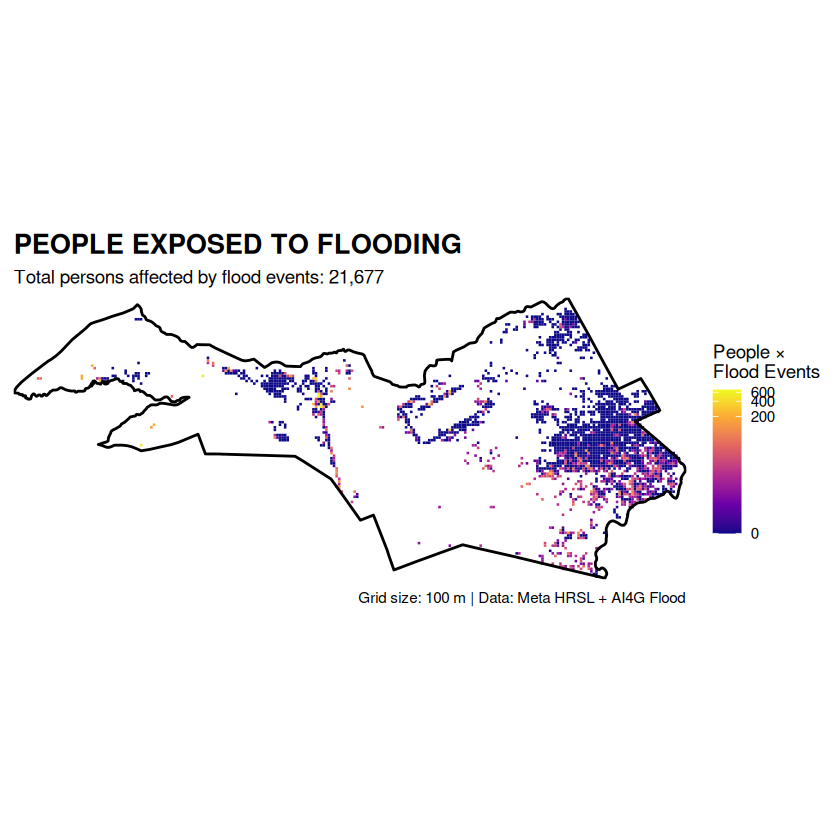

In [9]:
# Make sure grid_polygons contains the exposure metric
grid_exposure <- grid_polygons %>%
  left_join(
    flood_population %>%
      st_drop_geometry() %>%
      select(cell_x, cell_y, population_exposed),
    by = c("cell_x", "cell_y")
  )

bb <- st_bbox(subcounty)

ggplot() +
  # Grid as actual polygons
  geom_sf(
    data = grid_exposure,
    aes(fill = population_exposed),
    color = NA    # no borders between grid cells
  ) +
  # Subcounty boundary on top
  geom_sf(
    data = subcounty,
    fill = NA, color = "black", linewidth = 0.6
  ) +
  coord_sf(
    xlim = c(bb["xmin"], bb["xmax"]),
    ylim = c(bb["ymin"], bb["ymax"]),
    expand = FALSE,
    crs = st_crs(subcounty)
  ) +
  scale_fill_viridis_c(
    option = "plasma",
    trans = "log1p",
    name = "People ×\nFlood Events",
    labels = scales::comma,
    na.value = "grey95"
  ) +
  labs(
    title = "PEOPLE EXPOSED TO FLOODING",
    subtitle = paste(
      "Total persons affected by flood events:",
      scales::comma(sum(flood_population$population_exposed, na.rm = TRUE))
    ),
    caption = paste0("Grid size: ", grid_size, " m | Data: Meta HRSL + AI4G Flood")
  ) +
  theme_minimal() +
  theme(
    axis.text = element_blank(),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    plot.title = element_text(size = 16, face = "bold")
  )

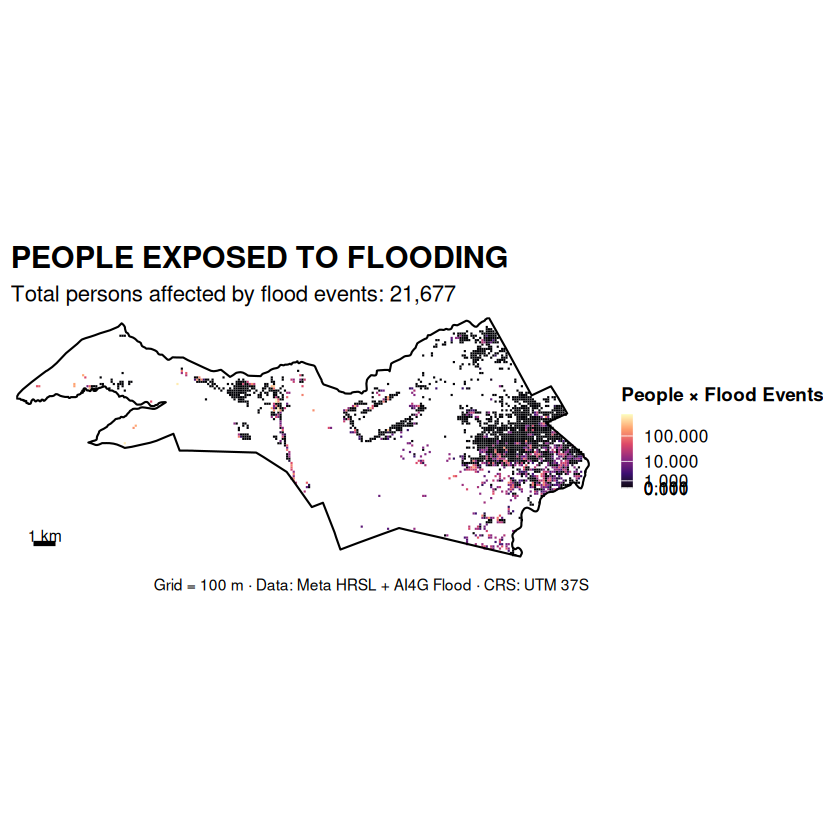

In [10]:
# --- JOIN EXPOSURE VALUES ---
grid_exposure <- grid_polygons %>%
  left_join(
    flood_population %>%
      st_drop_geometry() %>%
      select(cell_x, cell_y, population_exposed),
    by = c("cell_x", "cell_y")
  )

# --- MATCH CRS WITH OTHER CAPSTONE MAPS (UTM 37S) ---
target_crs <- "EPSG:32737"
subcounty_t      <- st_transform(subcounty, target_crs)
grid_exposure_t  <- st_transform(grid_exposure, target_crs)

# --- BOUNDING BOX (after transform) ---
bb <- st_bbox(subcounty_t)

# Legend breaks for a smoother log-scale
raw_vals   <- grid_exposure_t$population_exposed
raw_vals   <- raw_vals[raw_vals > 0]
leg_breaks <- scales::log_breaks(n = 7)(raw_vals)

total_exposed <- sum(flood_population$population_exposed, na.rm = TRUE)

p_expo <- ggplot() +

  # --- GRID CELLS ---
  geom_sf(
    data = grid_exposure_t,
    aes(fill = population_exposed),
    color = scales::alpha("white", 0.18),
    linewidth = 0.05
  ) +

  # --- SUBCOUNTY OUTLINE ---
  geom_sf(
    data = subcounty_t,
    fill = NA, color = "black", linewidth = 0.45
  ) +

  # --- SCALE BAR (1 km) ---
  annotate(
    "segment",
    x = bb["xmin"] + 800,  xend = bb["xmin"] + 1800,
    y = bb["ymin"] + 600,  yend = bb["ymin"] + 600,
    colour = "black", linewidth = 1.1
  ) +
  annotate(
    "text",
    x = bb["xmin"] + 1300,
    y = bb["ymin"] + 950,
    label = "1 km",
    size = 3.2, colour = "black"
  ) +

  # --- EXTENT ---
  coord_sf(
    xlim = c(bb["xmin"], bb["xmax"]),
    ylim = c(bb["ymin"], bb["ymax"]),
    expand = FALSE
  ) +

  # --- COLOR SCALE (magma + log1p) ---
  scale_fill_viridis_c(
    option = "magma",
    trans  = "log1p",
    breaks = leg_breaks,
    labels = scales::label_comma(),
    name   = "People × Flood Events",
    na.value = "grey95",
    guide = guide_colorbar(
      title.position = "top",
      barheight = unit(45, "pt"),
      barwidth  = unit(7, "pt"),
      ticks = TRUE
    )
  ) +

  # --- TITLES / LABELS ---
  labs(
    title = "PEOPLE EXPOSED TO FLOODING",
    subtitle = paste0(
      "Total persons affected by flood events: ",
      scales::comma(total_exposed)
    ),
    caption = paste0(
      "Grid = ", grid_size, " m · Data: Meta HRSL + AI4G Flood · CRS: UTM 37S"
    )
  ) +

  # --- THEME (MATCH YOUR CAPSTONE STYLE) ---
  theme_minimal(base_size = 13) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 11, face = "bold"),
    legend.text  = element_text(size = 10),

    plot.title    = element_text(size = 18, face = "bold"),
    plot.subtitle = element_text(size = 13),
    plot.caption  = element_text(size = 9, margin = margin(t = 10)),

    axis.text  = element_blank(),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    plot.title.position = "plot"
  )

p_expo

In [11]:
# VISUALIZATION 3: Spatial Risk Map
bb <- st_bbox(subcounty)

target_crs <- "EPSG:32737"

subcounty <- st_transform(subcounty, target_crs)
risk_grid <- st_transform(risk_grid, target_crs)

risk_grid <- risk_grid %>%
  mutate(
    risk_simple = recode(
      risk_category,
      "CRITICAL: Dense Chronic"    = "Severe frequent flooding",
      "HIGH: Chronic Flood Zone"   = "Regular flooding",
      "ELEVATED: Populated Repeat" = "Frequent flooding",
      "MODERATE: Repeat Flooding"  = "Occasional repeat flooding",
      "LOW: Some Population"       = "Rare flooding",
      "Minimal: Single Event"      = "Very rare",
      "UNPOPULATED"                = "Unpopulated")
  )


viz3 <- ggplot() +
  geom_sf(data = risk_grid, aes(fill = risk_simple), color = NA) +
  geom_sf(data = subcounty, fill = NA, color = "black", linewidth = 0.6) +  # <- subcounty boundary
  scale_fill_manual(values = risk_palette, drop = FALSE, na.value = "white") +
annotate("segment",
    x    = bb["xmin"] + 500, xend = bb["xmin"] + 1500,
    y    = bb["ymin"] + 300, yend = bb["ymin"] + 300,
    colour = "black", linewidth = 1.2
  ) +
  annotate("text",
    x     = bb["xmin"] + 1000,
    y     = bb["ymin"] + 600,
    label = "1 km",
    size  = 3, colour = "black"
  ) +
  coord_sf(
    xlim = c(bb["xmin"], bb["xmax"]),
    ylim = c(bb["ymin"], bb["ymax"]),
    expand = FALSE,
    crs = st_crs(subcounty)
  ) +
  labs(
    title = "Flood Risk Categories - Kasarani Subcounty",
     subtitle = paste(
      "Total persons affected by flood events:",
      scales::comma(sum(flood_population$population_exposed, na.rm = TRUE))),
    #subtitle = paste0("Grid size: ", "100", " m · Classification = Flood Frequency × Population"),
    fill = "Risk Category",
    x = NULL, 
    y = NULL,
    caption = "Author: Stacy Mwangi · 2025–2026 · Data: AI4G Flood + Meta HRSL · CRS: UTM 37S"
  ) +
  theme_minimal() +
  theme(
    legend.position = "right",
    axis.text = element_blank(),
    panel.grid = element_blank(),
    plot.title = element_text(face = "bold")
  )
viz3

ERROR: Error: object 'risk_grid' not found


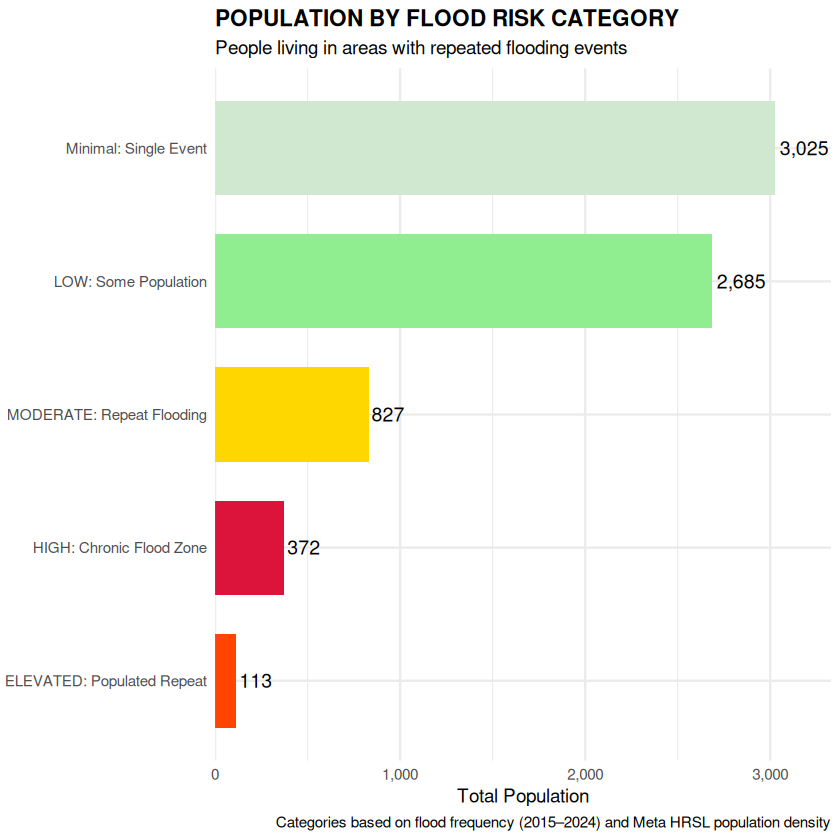

In [12]:
library(dplyr)
library(ggplot2)
library(scales)
library(forcats)
library(sf)

# Optional: ensure outputs dir
if (!dir.exists("outputs")) dir.create("outputs", recursive = TRUE)

# Define the full ordered set of risk categories used in your pipeline
risk_levels <- c(
  "UNPOPULATED",
  "Minimal: Single Event",
  "LOW: Some Population",
  "MODERATE: Repeat Flooding",
  "ELEVATED: Populated Repeat",
  "HIGH: Chronic Flood Zone",
  "CRITICAL: Dense Chronic"
)

# Your palette covers the populated categories (we keep it as‑is).
# We'll also add neutral colors for categories you didn't include, to avoid warnings.
risk_palette <- c(
  "CRITICAL: Dense Chronic"       = "#8B0000",
  "HIGH: Chronic Flood Zone"      = "#DC143C",
  "ELEVATED: Populated Repeat"    = "#FF4500",
  "MODERATE: Repeat Flooding"     = "#FFD700",
  "LOW: Some Population"          = "#90EE90",
  # add unobtrusive colors for the remaining levels to keep scale complete
  "Minimal: Single Event"         = "#CFE8CF",
  "UNPOPULATED"                   = "#E0E0E0"
)

# ---- FIXED SUMMARY ----
risk_summary <- flood_population %>%
  st_drop_geometry() %>%                                  # drop geometry for plain dplyr ops
  mutate(risk_category = factor(risk_category, levels = risk_levels)) %>%
  group_by(risk_category) %>%
  summarise(
    cells = n(),
    total_population = sum(population, na.rm = TRUE),
    total_flood_events = sum(flood_frequency, na.rm = TRUE),  # FIX: use flood_frequency
    .groups = "drop"
  ) %>%
  filter(total_population > 0) %>%                        # keep only populated categories
  arrange(desc(total_population))

# ---- BAR CHART ----
p_risk <- ggplot(
  risk_summary,
  aes(x = reorder(risk_category, total_population), y = total_population)
) +
  geom_col(aes(fill = risk_category), width = 0.7) +
  geom_text(
    aes(label = comma(round(total_population))),
    hjust = -0.1, size = 4
  ) +
  scale_fill_manual(values = risk_palette, drop = FALSE) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.1))) +
  coord_flip() +
  labs(
    title = "POPULATION BY FLOOD RISK CATEGORY",
    subtitle = "People living in areas with repeated flooding events",
    x = NULL,
    y = "Total Population",
    caption = "Categories based on flood frequency (2015–2024) and Meta HRSL population density"
  ) +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold"))

# Save (optional)
ggsave("outputs/population_by_risk_category.png", p_risk, width = 9, height = 5.5, dpi = 300)
ggsave("outputs/population_by_risk_category.pdf", p_risk, width = 9, height = 5.5, device = cairo_pdf)

p_risk

In [0]:
library(ggplot2)
library(sf)
library(dplyr)


# Join risk categories back to grid cells
risk_grid <- grid_polygons %>%
  left_join(
    flood_population %>%
      st_drop_geometry() %>%
      select(cell_x, cell_y, risk_category),
    by = c("cell_x", "cell_y")
  ) %>%
  mutate(risk_category = factor(risk_category, levels = risk_levels))

bb <- st_bbox(subcounty)

p_map <- ggplot() +
  geom_sf(data = risk_grid, aes(fill = risk_category), color = NA) +
  geom_sf(data = subcounty, fill = NA, color = "black", linewidth = 0.6) +  # <- subcounty boundary
  scale_fill_manual(values = risk_palette, drop = FALSE, na.value = "white") +
  coord_sf(
    xlim = c(bb["xmin"], bb["xmax"]),
    ylim = c(bb["ymin"], bb["ymax"]),
    expand = FALSE,
    crs = st_crs(subcounty)
  ) +
  labs(
    title = "Flood Risk Categories — Kasarani Subcounty",
    subtitle = paste0("Grid size: ", grid_size, " m · Classification = Flood Frequency × Population"),
    fill = "Risk Category",
    x = NULL, y = NULL,
    caption = "Author: Stacy Mwangi · 2025–2026 · Data: AI4G Flood + Meta HRSL · CRS: UTM 37S"
  ) +
  theme_minimal() +
  theme(
    legend.position = "right",
    axis.text = element_blank(),
    panel.grid = element_blank(),
    plot.title = element_text(face = "bold")
  )

# Save (optional)
ggsave("outputs/risk_category_map_with_boundary.png", p_map, width = 8, height = 8, dpi = 300)
ggsave("outputs/risk_category_map_with_boundary.pdf", p_map, width = 8, height = 8, device = cairo_pdf)

p_map

In [13]:
library(dplyr)
library(sf)
library(leaflet)
library(scales)
library(tidyr)   # for replace_na

# 1) Prepare rectangle corners in UTM 37S (meters)
rects_utm <- flood_population %>%
  st_drop_geometry() %>%
  mutate(
    # popups & color as you had them (and fix times_flooded -> flood_frequency)
    popup = paste0(
      "<b>Grid Cell:</b> ", round(cell_x), ", ", round(cell_y), "<br>",
      "<b>Times Flooded:</b> ", replace_na(flood_frequency, 0), "<br>",
      "<b>Population:</b> ", comma(round(replace_na(population, 0))), "<br>",
      "<b>Total Exposure:</b> ", comma(round(replace_na(population_exposed, 0))), " person-events<br>",
      "<b>Risk Level:</b> ", replace_na(risk_category, "UNPOPULATED")
    ),
    color = case_when(
      risk_category == "CRITICAL: Dense Chronic" ~ "#8B0000",
      risk_category == "HIGH: Chronic Flood Zone" ~ "#DC143C",
      risk_category == "ELEVATED: Populated Repeat" ~ "#FF4500",
      risk_category == "MODERATE: Repeat Flooding" ~ "#FFD700",
      TRUE ~ "#90EE90"
    ),
    # rectangle corners in UTM
    x1 = cell_x, y1 = cell_y,
    x2 = cell_x + grid_size, y2 = cell_y + grid_size
  )

# 2) Transform the two corners to lon/lat
ll_utm <- st_as_sf(rects_utm, coords = c("x1", "y1"), crs = 32737)
ur_utm <- st_as_sf(rects_utm, coords = c("x2", "y2"), crs = 32737)

ll_wgs <- st_transform(ll_utm, 4326)
ur_wgs <- st_transform(ur_utm, 4326)

# 3) Extract numeric lon/lat and bind back
rects_wgs <- rects_utm %>%
  mutate(
    lng1 = st_coordinates(ll_wgs)[, 1],
    lat1 = st_coordinates(ll_wgs)[, 2],
    lng2 = st_coordinates(ur_wgs)[, 1],
    lat2 = st_coordinates(ur_wgs)[, 2]
  )

# ---- NEW: transform subcounty to WGS84 for leaflet ----
subcounty_wgs <- st_transform(subcounty, 4326)

# 4) Render with Leaflet using lon/lat rectangle corners + subcounty boundary
m <- rects_wgs %>%
  leaflet() %>%
  addProviderTiles(providers$CartoDB.Positron) %>%
  addRectangles(
    lng1 = ~lng1, lat1 = ~lat1,
    lng2 = ~lng2, lat2 = ~lat2,
    color = ~color,
    fillOpacity = 0.6,
    weight = 1,
    popup = ~popup,
    group = "Risk Grid"
  ) %>%
  # ---- NEW: add subcounty outline ----
  addPolylines(
    data = subcounty_wgs,
    color = "black",
    weight = 2,
    opacity = 1,
    group = "Subcounty Boundary"
  ) %>%
  addLegend(
    position = "bottomright",
    colors = c("#8B0000", "#DC143C", "#FF4500", "#FFD700", "#90EE90"),
    labels = c("Critical", "High", "Elevated", "Moderate", "Low"),
    title = "Risk Category"
  ) %>%
  # (Optional) toggle control
  addLayersControl(
    overlayGroups = c("Risk Grid", "Subcounty Boundary"),
    options = layersControlOptions(collapsed = TRUE)
  )

# 5) Auto-zoom to the rectangles’ extent
bbox <- range(c(rects_wgs$lng1, rects_wgs$lng2), na.rm = TRUE)
latbox <- range(c(rects_wgs$lat1, rects_wgs$lat2), na.rm = TRUE)
m <- m %>% fitBounds(lng1 = bbox[1], lat1 = latbox[1], lng2 = bbox[2], lat2 = latbox[2])

m


Attaching package: ‘tidyr’




The following object is masked from ‘package:terra’:

    extract




HTML widgets cannot be represented in plain text (need html)

In [0]:
library(dplyr)
library(ggplot2)
library(sf)
library(scales)
library(purrr)

# --- 0) Ensure layers are in UTM 37S (EPSG:32737) ---
# (Do this once; if already transformed upstream you can skip)
subcounty_utm   <- st_transform(subcounty, 32737)
roads_clip_utm  <- st_transform(roads_clip, 32737)

# --- 1) Aggregate to grid level from road_flood_analysis ---
grid_roads <- road_flood_analysis %>%
  group_by(cell_x, cell_y) %>%
  summarise(
    total_road_km = sum(segment_length_m, na.rm = TRUE) / 1000,
    arterial_km   = sum(segment_length_m[road_class == "Arterial"], na.rm = TRUE) / 1000,
    flood_frequency = { v <- na.omit(flood_frequency); if (length(v) == 0) 0 else v[1] },
    population      = { v <- na.omit(population);      if (length(v) == 0) 0 else v[1] },
    .groups = "drop"
  ) %>%
  mutate(
    road_exposure_score = total_road_km * flood_frequency,
    priority = case_when(
      arterial_km > 0 & flood_frequency >= 10 ~ "CRITICAL ARTERIAL",
      arterial_km > 0 & flood_frequency >= 5  ~ "HIGH PRIORITY ARTERIAL",
      total_road_km > 0 & flood_frequency >= 10 ~ "CHRONIC LOCAL",
      total_road_km > 0 & flood_frequency >= 5  ~ "REPEAT LOCAL",
      TRUE ~ "LOW RISK"
    )
  )

# --- 2) Build sf grid polygons in UTM 37S ---
grid_polys <- grid_roads %>%
  mutate(
    geometry = purrr::map2(cell_x, cell_y, ~{
      st_polygon(list(matrix(c(
        .x,               .y,
        .x + grid_size,   .y,
        .x + grid_size,   .y + grid_size,
        .x,               .y + grid_size,
        .x,               .y
      ), ncol = 2, byrow = TRUE)))
    })
  ) %>%
  st_as_sf(crs = 32737)

# Subset of cells with any arterial road length (for black outline)
grid_polys_arterial <- dplyr::filter(grid_polys, arterial_km > 0)

# --- 3) Optional: style roads by class (Arterial vs. Other) ---
roads_clip_utm <- roads_clip_utm %>%
  mutate(
    road_style = ifelse(road_class == "Arterial", "Arterial", "Other")
  )

# Road drawing parameters
road_colors <- c(Arterial = "#1F77B4", Other = "#7F7F7F")
road_sizes  <- c(Arterial = 0.9,       Other = 0.4)

# --- 4) Plot with geom_sf: grid -> roads -> boundary ---
ggplot() +# Roads overlay (drawn above the grid, below the boundary)
  geom_sf(data = roads_clip_utm,
          aes(color = road_style, linewidth = road_style),
          alpha = 0.9, show.legend = "line") +
  # Heatmap by road exposure score
  geom_sf(data = grid_polys, aes(fill = road_exposure_score), color = NA) +
  # Optional black outline for cells intersecting arterial roads
  geom_sf(data = grid_polys_arterial, fill = NA, color = "black", linewidth = 0.5) +
  
  # Subcounty boundary on top
  geom_sf(data = subcounty_utm, fill = NA, color = "black", linewidth = 0.6) +
  # Scales
  scale_fill_gradientn(
    colors = c("#F7F7F7", "#FFD700", "#FF4500", "#8B0000"),
    trans  = "log1p",
    name   = "Road Exposure\n(km × floods)",
    labels = comma,
    na.value = "#F7F7F7"
  ) +
  scale_color_manual(values = road_colors, name = "Road class") +
  scale_linewidth_manual(values = road_sizes, guide = "none") +
  # CRS: UTM 37S (matches subcounty & grid)
  coord_sf(crs = st_crs(subcounty_utm)) +
  labs(
    title = "ROAD INFRASTRUCTURE FLOOD EXPOSURE",
    subtitle = "Arterial roads highlighted; grid fill shows km × flood frequency",
    caption = paste("Grid:", grid_size, "m · Chronic zones: ≥5 flood events · Data: OSM + Flood Records")
  ) +
  theme_minimal() +
  theme(
    axis.text = element_blank(),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    plot.title = element_text(size = 16, face = "bold"),
    legend.title = element_text(face = "bold")
  )

In [0]:
library(dplyr)
library(ggplot2)
library(scales)
library(forcats)

# Summarize exposure by road class and flood frequency
road_category_impact <- road_flood_analysis %>%
  group_by(road_class, flood_frequency) %>%
  summarise(
    total_km = sum(segment_length_m, na.rm = TRUE) / 1000,   # km
    segments = n_distinct(segment_id),
    .groups = "drop"
  ) %>%
  # Build flood tiers from numeric frequency
  mutate(
    flood_tier = case_when(
      is.na(flood_frequency)        ~ "No Floods",
      flood_frequency == 0          ~ "No Floods",
      flood_frequency %in% 1:2      ~ "Occasional",
      flood_frequency %in% 3:5      ~ "Regular",
      flood_frequency %in% 6:10     ~ "Chronic",
      flood_frequency > 10          ~ "Severe Chronic",
      TRUE                          ~ "No Floods"
    ),
    flood_tier = factor(
      flood_tier,
      levels = c("No Floods", "Occasional", "Regular", "Chronic", "Severe Chronic")
    )
  )

# (Optional) reorder road classes by total km for a nicer x-axis
road_order <- road_category_impact %>%
  group_by(road_class) %>%
  summarise(class_km = sum(total_km, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(class_km)) %>%
  pull(road_class)

road_category_impact <- road_category_impact %>%
  mutate(road_class = factor(road_class, levels = road_order))

# Plot
ggplot(road_category_impact, aes(x = road_class, y = total_km, fill = flood_tier)) +
  geom_col(position = "stack", width = 0.75) +
  scale_fill_manual(
    values = c(
      "No Floods"      = "#E0E0E0",
      "Occasional"     = "#90EE90",
      "Regular"        = "#FFD700",
      "Chronic"        = "#FF4500",
      "Severe Chronic" = "#8B0000"
    ),
    drop = FALSE
  ) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "ROAD NETWORK EXPOSURE BY CATEGORY",
    subtitle = "Kilometers of road segments by flood frequency tier",
    x = "Road Class",
    y = "Total Road Length (km)",
    fill = "Flood Frequency",
    caption = "Arterial corridors with chronic flooding should be evaluated for mitigation or rerouting."
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 16, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

In [0]:
library(dplyr)
library(sf)
library(leaflet)
library(leaflet.extras)
library(scales)
library(purrr)
library(tidyr)   # replace_na

# ---- 0) Helper: coerce to sf if needed -------------------------------------
ensure_sf <- function(obj, crs = 32737, geometry_col = "geometry", join_source = NULL, by = NULL) {
  if (inherits(obj, "sf")) return(obj)
  # If it has a geometry column we can coerce directly
  if (!is.null(geometry_col) && geometry_col %in% names(obj)) {
    return(st_as_sf(obj, crs = crs))
  }
  # Else if a join source is provided, try to join geometry in
  if (!is.null(join_source) && !is.null(by)) {
    obj2 <- obj %>%
      left_join(join_source %>% select(all_of(c(by, geometry_col))), by = by)
    if (geometry_col %in% names(obj2)) {
      return(st_as_sf(obj2, crs = crs))
    } else {
      stop("Failed to attach geometry via join_source; no 'geometry' column found after join.")
    }
  }
  stop("Object is not sf and no geometry column found. Provide a join_source or geometry.")
}

# ---- 1) Ensure inputs are sf in EPSG:32737 (UTM 37S) -----------------------

# roads_clip: should already be sf; coerce if needed (no join necessary)
roads_clip_utm <- ensure_sf(roads_clip, crs = 32737)

# subcounty: should already be sf; coerce if needed
subcounty_utm <- ensure_sf(subcounty, crs = 32737)

# road_flood_analysis: ideally an sf; if it's a data.frame,
#   try to coerce via its 'geometry' column; if missing, join geometry from roads_clip by 'osm_id'
road_flood_analysis_utm <- tryCatch(
  ensure_sf(road_flood_analysis, crs = 32737, geometry_col = "geometry",
            join_source = roads_clip_utm, by = "osm_id"),
  error = function(e) {
    stop("road_flood_analysis needs geometry. Ensure it retains 'geometry' or provide 'roads_clip' to join by 'osm_id'.\n", e$message)
  }
)
# ---- 3) Build chronic flood grids (>=5 floods) as sf polygons --------------
chronic_grids_utm <- flood_population %>%
  st_drop_geometry() %>%
  filter(flood_frequency >= 5) %>%
  distinct(cell_x, cell_y, .keep_all = TRUE) %>%
  mutate(
    geometry = purrr::map2(cell_x, cell_y, ~{
      st_polygon(list(matrix(c(
        .x,               .y,
        .x + grid_size,   .y,
        .x + grid_size,   .y + grid_size,
        .x,               .y + grid_size,
        .x,               .y
      ), ncol = 2, byrow = TRUE)))
    })
  ) %>%
  st_as_sf(crs = 32737)
# ---- 2) Identify critical segments (Arterial/Collector + chronic >= 5) -----
critical_roads_utm <- road_flood_analysis_utm %>%
  filter(road_class %in% c("Arterial", "Collector"),
         flood_frequency >= 5) %>%
  mutate(
    popup = paste0(
      "<b>Road:</b> ", replace_na(name, "Unnamed"), "<br>",
      "<b>Type:</b> ", replace_na(highway, "NA"), "<br>",
      "<b>Times Flooded:</b> ", replace_na(flood_frequency, 0), "<br>",
      "<b>Segment Length:</b> ", comma(round(replace_na(segment_length_m, 0))), " m<br>",
      "<b>Population in Grid:</b> ", comma(round(replace_na(population, 0))), "<br>",
      "<b>Risk:</b> ", replace_na(risk_category, "NA")
    ),
    color = case_when(
      flood_frequency >= 10 ~ "#8B0000", # Severe
      flood_frequency >= 7  ~ "#DC143C", # High
      flood_frequency >= 5  ~ "#FF4500", # Elevated
      TRUE ~ "#90EE90"
    ),
    weight = ifelse(road_class == "Arterial", 4, 2)
  )



# ---- 4) Transform to WGS84 for Leaflet -------------------------------------
critical_roads_ll <- st_transform(critical_roads_utm, 4326)
chronic_grids_ll  <- st_transform(chronic_grids_utm,  4326)
roads_clip_ll     <- st_transform(roads_clip_utm,     4326)
subcounty_ll      <- st_transform(subcounty_utm,      4326)

# Classify context roads
roads_clip_ll <- roads_clip_ll %>%
  mutate(road_style = ifelse(road_class %in% c("Arterial", "Collector"), "Arterial/Collector", "Other"))

# ---- 5) Build Leaflet map ---------------------------------------------------
m2 <- leaflet(options = leafletOptions(worldCopyJump = FALSE)) %>%
  addProviderTiles(providers$CartoDB.Positron) %>%

  # Chronic flood grids layer
  addPolygons(
    data = chronic_grids_ll,
    fillColor = "#FF4500",
    fillOpacity = 0.2,
    color = NA,
    stroke = FALSE,
    group = "Chronic Flood Grids (≥5)"
  ) %>%

  # Context Roads
  addPolylines(
    data = roads_clip_ll %>% filter(road_style == "Other"),
    color = "#9E9E9E",
    weight = 1,
    opacity = 0.8,
    group = "All Roads (context)"
  ) %>%
  addPolylines(
    data = roads_clip_ll %>% filter(road_style == "Arterial/Collector"),
    color = "#1F77B4",
    weight = 2.5,
    opacity = 0.9,
    group = "Arterial/Collector (context)"
  ) %>%

  # Critical segments (arterial/collector + >=5 floods)
  addPolylines(
    data = critical_roads_ll,
    color = ~color,
    weight = ~weight,
    opacity = 0.95,
    popup = ~popup,
    group = "Critical Road Segments"
  ) %>%

  # Subcounty boundary
  addPolylines(
    data = subcounty_ll,
    color = "black",
    weight = 2,
    opacity = 1,
    group = "Subcounty Boundary"
  ) %>%

  addLayersControl(
    overlayGroups = c("Chronic Flood Grids (≥5)",
                      "All Roads (context)",
                      "Arterial/Collector (context)",
                      "Critical Road Segments",
                      "Subcounty Boundary"),
    options = layersControlOptions(collapsed = FALSE)
  ) %>%
  addLegend(
    position = "bottomright",
    colors = c("#8B0000", "#DC143C", "#FF4500"),
    labels = c("10+ floods", "7–9 floods", "5–6 floods"),
    title = "Road Vulnerability"
  )

# Fit to subcounty extent (fallback to grids if needed)
if (nrow(st_drop_geometry(subcounty_ll)) > 0) {
  bb <- st_bbox(subcounty_ll)
  m <- m %>% fitBounds(lng1 = bb["xmin"], lat1 = bb["ymin"], lng2 = bb["xmax"], lat2 = bb["ymax"])
} else if (nrow(st_drop_geometry(chronic_grids_ll)) > 0) {
  bb <- st_bbox(chronic_grids_ll)
  m <- m %>% fitBounds(lng1 = bb["xmin"], lat1 = bb["ymin"], lng2 = bb["xmax"], lat2 = bb["ymax"])
}

m2

In [0]:
# ---- Packages ----
library(dplyr)
library(sf)           # for st_drop_geometry()
library(tidyr)        # for replace_na()
library(scales)       # for comma()
library(tibble)

# Option A (static)
suppressPackageStartupMessages({
  library(knitr)
  library(kableExtra)
})

# Option B (interactive)
suppressPackageStartupMessages({
  library(DT)
  library(htmltools)
})

# ---- 1) Data prep: summarize by road_class for cells with >= 5 floods ----
bt_raw <- road_flood_analysis %>%
  st_drop_geometry() %>%                                  # remove sf geometry list-col
  select(road_class, segment_id, segment_length_m, flood_frequency, population) %>%
  mutate(
    segment_length_m = as.numeric(segment_length_m),
    flood_frequency  = as.numeric(flood_frequency),
    population       = as.numeric(population)
  ) %>%
  filter(!is.na(road_class), flood_frequency >= 5) %>%
  group_by(road_class) %>%
  summarise(
    total_km            = sum(segment_length_m, na.rm = TRUE) / 1000,
    segments_affected   = n_distinct(segment_id),
    avg_floods_segment  = mean(flood_frequency, na.rm = TRUE),
    max_floods          = max(flood_frequency, na.rm = TRUE),
    population_served   = sum(population, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(total_km)) %>%
  tibble::as_tibble()

# Zero-row guard
if (nrow(bt_raw) == 0) {
  bt_raw <- tibble::tibble(
    road_class           = "(no segments ≥5 floods)",
    total_km             = 0,
    segments_affected    = 0,
    avg_floods_segment   = 0,
    max_floods           = 0,
    population_served    = 0
  )
}

# ---- 2) Presentation frame for rendering ----
bt_fmt <- bt_raw %>%
  mutate(
    `Road Class`          = road_class,
    `Total Length (km)`   = sprintf("%.1f", total_km),
    `Segments Affected`   = comma(segments_affected),
    `Avg Floods/Segment`  = sprintf("%.1f", avg_floods_segment),
    `Max Floods`          = comma(round(max_floods)),
    `Population Served`   = comma(round(population_served))
  ) %>%
  select(
    `Road Class`,
    `Total Length (km)`,
    `Segments Affected`,
    `Avg Floods/Segment`,
    `Max Floods`,
    `Population Served`
  )

# =========================
# Option A — kableExtra
# =========================
tbl_kable <- knitr::kable(
  bt_fmt,
  format  = "html",
  align   = c("l", "r", "r", "r", "r", "r"),
  caption = "ROAD INFRASTRUCTURE AT RISK — Segments in areas with 5+ flood events (2015–2024)"
) %>%
  kable_styling(full_width = TRUE, bootstrap_options = c("striped", "condensed", "hover"))

# Highlight 'Arterial' rows
arterial_rows <- which(bt_fmt[["Road Class"]] == "Arterial")
if (length(arterial_rows) > 0) {
  tbl_kable <- tbl_kable %>%
    row_spec(arterial_rows, background = "#FFE5E5")
}

# Footnote
tbl_kable <- tbl_kable %>%
  footnote(
    general       = "Population estimates from Meta HRSL (2020) within 100 m grid cells.",
    general_title = "Note: "
  )

# Print kable table
tbl_kable

# (Optional) Save to HTML
# if (!dir.exists("outputs")) dir.create("outputs", recursive = TRUE)
# save_kable(tbl_kable, "outputs/road_infrastructure_at_risk.html")


# =========================
# Option B — DT (interactive)
# =========================
dt <- datatable(
  bt_fmt,
  rownames = FALSE,
  caption = tags$caption(
    style = 'caption-side: top; text-align: left; font-weight: bold;',
    "ROAD INFRASTRUCTURE AT RISK — Segments in areas with 5+ flood events (2015–2024)"
  ),
  options = list(
    pageLength = 10,
    autoWidth  = TRUE,
    dom        = 'tip',
    order      = list(list(1, 'desc'))  # sort by Total Length (km)
  )
)

# ✅ Correct highlighting: specify the column *name as a string* and use styleEqual levels/values
dt <- formatStyle(
  dt,
  "Road Class",                        # <- column name as string
  target = "row",
  backgroundColor = styleEqual(
    levels = c("Arterial"),
    values = c("#FFE5E5")
  )
)

dt

In [0]:
library(sf)

st_write(
  risk_grid,
  "/home/user/course-5-data-communication/module-15/pset-student/risk_grid.gpkg"
)



## Ethical Considerations
- Privacy: The dataset does not contain personal data.
- Governance: Data used is openly available and ethically sourced.
- Bias: Consideration of potential biases in dataset and analysis.

## Acknowledging Limitations
*In 1-2 sentences, acknowledge any limitations of your data or analysis.*

Relevant Lectures:
<br>**Course 3, Module 8**: "Handling Data Anomalies" by Angel — Discusses how to handle data anomalies and understand the limitations of your data.</br>

The analysis is based on the `mpg` dataset, which may have limitations such as:
- Limited scope: Only includes data available and may not capture the entire spectrum of vehicle data.
- Data quality: Possible measurement errors or missing values.

## Results for Non-Technical Audience
*In 1-2 sentences, explain the results of your analysis to a non-technical audience and the implications of your results for your environmental topic.*

Relevant Lectures:
<br>**Course 5, Module 15**: "Turning Data into Action" by Denice Ross — Discusses strategies for communicating results to a non-technical audience.</br>

Fuel economy varies significantly across different vehicle classes. Smaller and more efficient engines generally achieve higher miles per gallon (MPG) on the highway. Manufacturers show varying performance in terms of fuel economy, with some focusing on more efficient vehicles.

## Instructions for Reproducing Project
*Describe the steps someone else would need to take to reproduce your project.*
Relevant Lectures:
<br>**Course 2, Module 6**: "Addressing Version Control and Reproducibility" by Mitch — Explains the importance and strategies for version control.</br>
<br>**Course 4, Module 14**: "Creating Data Visualizations for EDA" by JRS — Provides guidance on reproducible EDA practices.</br>

1. Clone the GitHub repository.
2. Ensure you have R and the required libraries installed (`dplyr`, `ggplot2`).
3. Open and run the provided Jupyter notebook.